In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# ============================================================
# ГЛОБАЛЬНЫЕ КОНСТАНТЫ
# ============================================================
C_SI = 299792458.0

# ============================================================
# ОПТИЧЕСКИЕ МАТЕРИАЛЫ (Формулы Селмейера)
# ============================================================

class Material:
    def get_n(self, lambda_um, pol="o"): 
        raise NotImplementedError

class Air(Material):
    def get_n(self, lambda_um, pol="o"):
        lam2 = np.asarray(lambda_um) ** 2
        return 1 + 0.05792105 / (238.0185 - 1/lam2) + 0.00167917 / (57.362 - 1/lam2)

class BBO(Material):
    def get_n(self, lambda_um, pol="o"):
        lam2 = np.asarray(lambda_um) ** 2
        if pol == "o":
            n2 = 0.90291 * lam2 / (lam2 - 0.003926) + 0.83155 * lam2 / (lam2 - 0.018786) + 0.76536 * lam2 / (lam2 - 60.01) + 1
        elif pol == "e":
            n2 = 1.151075 * lam2 / (lam2 - 0.007142) + 0.21803 * lam2 / (lam2 - 0.02259) + 0.656 * lam2 / (lam2 - 263) + 1
        return np.sqrt(n2)
    
    def get_n_eff(self, lambda_um, psi_rad):
        n_o = self.get_n(lambda_um, "o")
        n_e = self.get_n(lambda_um, "e")
        return 1.0 / np.sqrt((np.cos(psi_rad)**2) / (n_o**2) + (np.sin(psi_rad)**2) / (n_e**2))

class GlassBK7(Material):
    def get_n(self, lambda_um, pol="o"):
        lam2 = np.asarray(lambda_um) ** 2
        B1, B2, B3 = 1.03961212, 0.231792344, 1.01046945
        C1, C2, C3 = 0.00600069867, 0.0200179144, 103.560653
        n2 = 1 + (B1 * lam2 / (lam2 - C1)) + (B2 * lam2 / (lam2 - C2)) + (B3 * lam2 / (lam2 - C3))
        return np.sqrt(n2)

# ============================================================
# СТРУКТУРА СЛОЯ
# ============================================================

class Layer:
    def __init__(self, material, thickness, pol_p="o", pol_s="o", pol_i="o", is_source=False, name="Слой"):
        self.material = material
        self.thickness = thickness
        self.pol_p = pol_p
        self.pol_s = pol_s
        self.pol_i = pol_i
        self.is_source = is_source
        self.name = name

# ============================================================
# КЛАСС ЭКСПЕРИМЕНТА (Основной управляющий элемент)
# ============================================================
class SPDCExperiment:
    def __init__(self, layers=None, lambda_pump_nm=404.0):
        self.layers = layers if layers is not None else []
        self.lambda_pump_nm = lambda_pump_nm
        self.w_pump = 2 * np.pi * C_SI / (lambda_pump_nm * 1e-9)
        self.psi_cut = self._find_bbo_cut_angle()

    def _find_bbo_cut_angle(self):
        """Внутренний метод для автоматического поиска угла синхронизма BBO."""
        bbo = BBO()
        lam_p_um = self.lambda_pump_nm * 1e-3
        lam_s_um = lam_p_um * 2
        n_s_deg = bbo.get_n(lam_s_um, "o")
        sol = root_scalar(lambda psi: bbo.get_n_eff(lam_p_um, psi) - n_s_deg, bracket=[0, np.pi/2])
        return sol.root

    def add_layer(self, layer):
        """Позволяет динамически добавлять слои в систему."""
        self.layers.append(layer)

    def clear_layers(self):
        """Очистить конфигурацию эксперимента."""
        self.layers = []

    def calculate_jsa(self, w_s, q_s):
        """Рассчитывает комплексную амплитуду бифотонов для текущих сеток частот и импульсов."""
        F_total = np.zeros_like(w_s, dtype=complex)
        accumulated_phase = np.zeros_like(w_s, dtype=complex)
        
        w_i = self.w_pump - w_s
        lam_p_um = (2 * np.pi * C_SI / self.w_pump) * 1e6
        lam_s_um = (2 * np.pi * C_SI / w_s) * 1e6
        lam_i_um = (2 * np.pi * C_SI / w_i) * 1e6

        for layer in self.layers:
            n_s = layer.material.get_n(lam_s_um, layer.pol_s)
            n_i = layer.material.get_n(lam_i_um, layer.pol_i)
            
            k_s = n_s * w_s / C_SI
            k_i = n_i * w_i / C_SI
            
            k_sz = np.sqrt(np.clip(k_s**2 - q_s**2, 0, None))
            k_iz = np.sqrt(np.clip(k_i**2 - q_s**2, 0, None))
            
            if layer.is_source:
                if isinstance(layer.material, BBO) and layer.pol_p == "eff":
                    n_p = layer.material.get_n_eff(lam_p_um, self.psi_cut)
                else:
                    n_p = layer.material.get_n(lam_p_um, layer.pol_p)
                k_p = n_p * self.w_pump / C_SI
                
                dk = k_p - k_sz - k_iz
                sinc_part = np.sinc(dk * layer.thickness / (2 * np.pi))
                layer_amplitude = layer.thickness * sinc_part * np.exp(1j * dk * layer.thickness / 2)
                
                F_total += layer_amplitude * np.exp(1j * accumulated_phase)
                accumulated_phase += dk * layer.thickness
            else:
                n_p_layer = layer.material.get_n(lam_p_um, layer.pol_p)
                k_p_layer = n_p_layer * self.w_pump / C_SI
                
                dk_layer = k_p_layer - k_sz - k_iz
                accumulated_phase += dk_layer * layer.thickness
                
        return F_total

    def run_angular_phase_benchmark(self, theta_deg_list=[0.0, 0.2, 0.5, 1.0, 1.5, 2.0]):
        """Бенчмарк: выводит относительный набег фазы d𝜙(𝜃) для каждого линейного слоя."""
        print("\n" + "="*80)
        print(" ООП БЕНЧМАРК: Набег относительной фазы d𝜙(𝜃) в линейных слоях схемы")
        print(" (Зафиксирован вырожденный режим 808 нм. Относительно центра оси 𝜃 = 0°)")
        print("="*80)
        
        air_ref = Air()
        w_s_deg = self.w_pump / 2
        lam_p_um, lam_s_um = self.lambda_pump_nm * 1e-3, (self.lambda_pump_nm * 2) * 1e-3
        
        k_air_s = air_ref.get_n(lam_s_um) * w_s_deg / C_SI

        for layer in self.layers:
            if layer.is_source:
                continue
                
            print(f"\n>> Анализ слоя: {layer.name} (Толщина: {layer.thickness*1e3:.2f} мм)")
            print("-" * 65)
            
            n_p_0 = layer.material.get_n(lam_p_um, layer.pol_p)
            n_s_0 = layer.material.get_n(lam_s_um, layer.pol_s)
            k_p_0 = n_p_0 * self.w_pump / C_SI
            k_s_0 = n_s_0 * w_s_deg / C_SI
            
            dk_0 = k_p_0 - 2 * k_s_0
            phase_0 = dk_0 * layer.thickness
            
            for theta_deg in theta_deg_list:
                q_s = k_air_s * np.sin(np.radians(theta_deg))
                
                n_p = layer.material.get_n(lam_p_um, layer.pol_p)
                n_s = layer.material.get_n(lam_s_um, layer.pol_s)
                
                k_p = n_p * self.w_pump / C_SI
                k_s = n_s * w_s_deg / C_SI
                
                k_sz = np.sqrt(np.clip(k_s**2 - q_s**2, 0, None))
                dk_theta = k_p - 2 * k_sz
                phase_theta = dk_theta * layer.thickness
                
                delta_phase = phase_theta - phase_0
                turns = delta_phase / (2 * np.pi)
                
                print(f"  Угол 𝜃 = {theta_deg:3.1f}° | Относит. фаза = {delta_phase:7.2f} рад | Проворотов (𝜙/2𝜋) = {turns:6.2f}")
        print("="*80 + "\n")

    # ============================================================
    # ОБНОВЛЕННЫЙ МЕТОД ПОСТРОЕНИЯ КАРТИНКИ
    # ============================================================
    def plot_experiment_image(self, lambda_range_nm=(700, 900), theta_range_deg=(-2.0, 2.0), 
                              lambda_count=1000, theta_count=1000):
        """
        Строит и выводит 2D-картину распределения интенсивности СПР.
        
        Параметры:
        ----------
        lambda_range_nm : tuple
            Минимальная и максимальная длина волны спектрометра (в нм).
        theta_range_deg : tuple
            Минимальный и максимальный внешний угол вылета (в градусах).
        lambda_count : int
            Разрешение по оси длин волн (количество точек).
        theta_count : int
            Разрешение по оси углов (количество точек).
        """
        # Прямая генерация сетки углов в радианах из заданного диапазона в градусах
        theta_array = np.radians(np.linspace(theta_range_deg[0], theta_range_deg[1], theta_count))
        lambdas_nm = np.linspace(lambda_range_nm[0], lambda_range_nm[1], lambda_count)

        w_signal_array = 2 * np.pi * C_SI / (lambdas_nm * 1e-9)
        w_s_mesh, theta_s_mesh = np.meshgrid(w_signal_array, theta_array)

        # q_s через воздух снаружи
        air_ref = Air()
        n_air_mesh = air_ref.get_n((2 * np.pi * C_SI / w_s_mesh) * 1e6)
        k_air_mesh = n_air_mesh * w_s_mesh / C_SI
        q_s_mesh = k_air_mesh * np.sin(theta_s_mesh)

        # Расчет
        F = self.calculate_jsa(w_s_mesh, q_s_mesh)
        Intensity = np.abs(F) ** 2
        
        # Защита от деления на ноль, если интенсивность всюду нулевая
        max_int = np.max(Intensity)
        if max_int > 0:
            Intensity /= max_int

        # Отрисовка
        plt.figure(figsize=(11, 6.5))
        plt.imshow(
            Intensity, 
            extent=[lambdas_nm.min(), lambdas_nm.max(), theta_range_deg[0], theta_range_deg[1]],
            aspect='auto', origin='lower', cmap='jet'
        )
        plt.colorbar(label='Нормированная интенсивность света')
        plt.title('ООП Модель: Распределение интенсивности СПР на матрице спектрометра')
        plt.xlabel('Длина волны $\lambda_s$, нм (Развертка призмы)')
        plt.ylabel('Внешний угол вылета $\theta$, град')
        plt.grid(True, alpha=0.25, linestyle='--')
        plt.show()

    def get_spectrum_bounded(self, lambdas_nm, theta_lims_deg=(-0.3, 0.3), theta_points=200):
        """
        Возвращает 1D-спектр интенсивности, проинтегрированный по заданному угловому окну.
        
        Параметры:
        ----------
        lambdas_nm : np.ndarray
            Массив длин волн (ось X).
        theta_lims_deg : tuple (theta_min, theta_max)
            Пределы обрезки апертуры в градусах, например (-0.3, 0.3).
        theta_points : int
            Количество точек сетки интегрирования внутри апертуры.
        """
        # 1. Создаем сетку углов внутри диафрагмы
        angles_rad = np.radians(np.linspace(theta_lims_deg[0], theta_lims_deg[1], theta_points))
        
        # 2. Считаем 2D матрицу интенсивности для этой области углов
        img_2d = self.get_simulated_image(lambdas_nm, angles_rad)
        
        # 3. Интегрируем по оси углов (ось 0) методом трапеций
        spectrum = np.trapz(img_2d, x=angles_rad, axis=0)
        
        return spectrum


<>:225: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:225: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\RedBrean\AppData\Local\Temp\ipykernel_9488\1120869239.py:225: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('Длина волны $\lambda_s$, нм (Развертка призмы)')


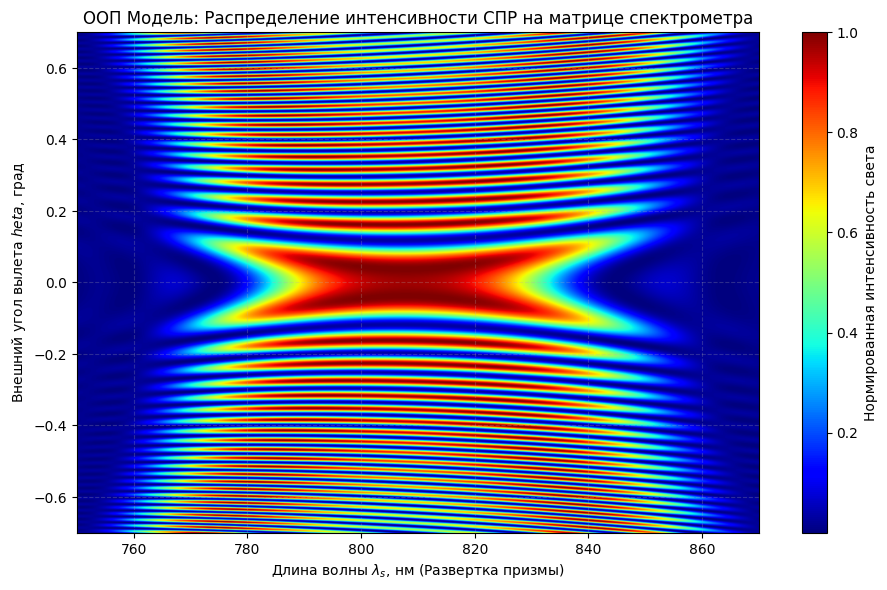

In [10]:
# Инициализируем материалы
air = Air()
bbo = BBO()
glass = GlassBK7()

# Создаем объект эксперимента (накачка 404 нм задана внутри по умолчанию)
experiment = SPDCExperiment()

# Набираем слои («пирог» нашего стенда)
experiment.add_layer(Layer(bbo, thickness=3.0e-3, pol_p="eff", is_source=True, name="Кристалл 1 (BBO)"))
experiment.add_layer(Layer(air, thickness=104e-3, is_source=False, name="Воздушный зазор 1"))
experiment.add_layer(Layer(bbo, thickness=4.3e-3, pol_p="eff", is_source=True, name="Кристалл 2 (BBO)"))

# 2. Строим 2D картинку интерференции, которая полетит на камеру спектрометра
experiment.plot_experiment_image(theta_range_deg=(-0.7, 0.7), lambda_range_nm=(750, 870))

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def generate_and_save_plots_by_gap(experiment, gap_params=(10e-3, 50e-3, 0.5e-3), rows=3, cols=5):
    """
    Генерирует матрицу интерференционных картинок (rows x cols), где параметр - 
    толщина воздушного слоя (расстояние между кристаллами).
    
    Параметры:
    ----------
    experiment : SPDCExperiment
        Объект эксперимента.
    gap_params : tuple (start, end, step)
        Начало, конец и шаг для толщины воздушного слоя в МЕТРАХ.
        Например, (0.0005, 0.0025, 0.0005) для диапазона от 0.5 до 2.5 мм.
    rows : int
        Количество строк в сетке.
    cols : int
        Количество столбцов в сетке.
    """
    # -------------------------------------------------------------------------
    # 1. ПОДГОТОВКА ДАННЫХ
    # -------------------------------------------------------------------------
    start, end, step = gap_params
    # Используем arange с небольшим смещением, чтобы включить конечную точку
    gap_values = np.arange(start, end + step/2, step)
    print(f"Расчет для толщин слоя: {gap_values * 1e3} мм")

    lambda_range_nm = (750, 870)
    theta_range_deg = (-0.3, 0.3)
    lambda_count, theta_count = 300, 300
    theta_array = np.radians(np.linspace(theta_range_deg[0], theta_range_deg[1], theta_count))
    lambdas_nm = np.linspace(lambda_range_nm[0], lambda_range_nm[1], lambda_count)
    
    # Вспомогательные константы и объекты (предполагается, что они доступны в области видимости)
    # Если нет, их нужно передать или определить внутри
    w_signal_array = 2 * np.pi * C_SI / (lambdas_nm * 1e-9)
    w_s_mesh, theta_s_mesh = np.meshgrid(w_signal_array, theta_array)
    
    air_ref = Air()
    glass_ref = GlassBK7()
    n_air_mesh = air_ref.get_n((2 * np.pi * C_SI / w_s_mesh) * 1e6)
    k_air_mesh = n_air_mesh * w_s_mesh / C_SI
    q_s_mesh = k_air_mesh * np.sin(theta_s_mesh)
    n_glass_center = glass_ref.get_n(0.808)
    
    # -------------------------------------------------------------------------
    # 2. ГЕНЕРАЦИЯ МАТРИЦЫ ИНТЕРФЕРЕНЦИИ (Grid Plot)
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(rows, cols, figsize=(18, 14), sharex=True, sharey=True)
    axes_flat = np.atleast_1d(axes).flatten()
    
    print("Расчет матрицы интерференции (зависимость от зазора)...")
    for i in range(rows * cols):
        ax = axes_flat[i]
        
        if i < len(gap_values):
            current_gap = gap_values[i]
            
            # Устанавливаем толщину воздушного слоя (слой 2)
            experiment.layers[2].thickness = current_gap
            
            F = experiment.calculate_jsa(w_s_mesh, q_s_mesh)
            Intensity = np.abs(F) ** 2
            
            if np.max(Intensity) > 0:
                Intensity /= np.max(Intensity)
            
            ax.imshow(
                Intensity, 
                extent=[lambdas_nm.min(), lambdas_nm.max(), theta_range_deg[0], theta_range_deg[1]],
                aspect='auto', origin='lower', cmap='jet'
            )
            ax.set_title(f"Gap = {current_gap*1e3:.2f} mm", fontsize=10, fontweight='bold')
            
            if i >= (rows - 1) * cols:
                ax.set_xlabel("$\\lambda_s$, нм", fontsize=10)
            if i % cols == 0:
                ax.set_ylabel("$\\theta$, град", fontsize=10)
            ax.grid(True, alpha=0.15, linestyle='--')
        else:
            ax.set_visible(False)
            
    plt.tight_layout()
    plt.savefig("spdc_interference_grid_by_gap.png", dpi=200)
    plt.close()
    print(f"Матричный график сохранен: 'spdc_interference_grid_by_gap.png'")

    # -------------------------------------------------------------------------
    # 3. СРЕЗ ПО УГЛАМ ДЛЯ СРЕДНЕГО ЗНАЧЕНИЯ ЗАЗОРА
    # -------------------------------------------------------------------------
    # Берем среднее значение из диапазона для примера
    mean_gap = np.mean(gap_values)
    experiment.layers[2].thickness = mean_gap
    
    print(f"Расчет среза для среднего зазора {mean_gap*1e3:.2f} мм...")
    theta_count_slice = 1000
    theta_array_slice = np.radians(np.linspace(theta_range_deg[0], theta_range_deg[1], theta_count_slice))
    w_s_fixed = 2 * np.pi * C_SI / (808.0 * 1e-9)
    k_air_slice = air_ref.get_n(0.808) * w_s_fixed / C_SI
    q_s_array_slice = k_air_slice * np.sin(theta_array_slice)
    w_s_array_slice = np.full_like(q_s_array_slice, w_s_fixed)
    
    F_slice = experiment.calculate_jsa(w_s_array_slice, q_s_array_slice)
    Intensity_slice = np.abs(F_slice) ** 2
    if np.max(Intensity_slice) > 0:
        Intensity_slice /= np.max(Intensity_slice)
        
    plt.figure(figsize=(8.5, 5))
    plt.plot(np.degrees(theta_array_slice), Intensity_slice, color='crimson', lw=2.5, label=f'$\\lambda = 808$ нм, Gap = {mean_gap*1e3:.2f} mm')
    plt.title(f'Срез интенсивности (углы) при зазоре {mean_gap*1e3:.2f} мм', fontsize=12)
    plt.xlabel('Внешний угол вылета $\\theta$, град', fontsize=10)
    plt.ylabel('Нормированная интенсивность', fontsize=10)
    plt.grid(True, alpha=0.25, linestyle='--')
    plt.legend()
    plt.tight_layout()
    plt.savefig("spdc_theta_slice_by_gap.png", dpi=200)
    plt.close()
    print(f"Срез сохранен в 'spdc_theta_slice_by_gap.png'")

# Пример вызова (укажите ваши параметры):
# generate_and_save_plots_by_gap(experiment, gap_params=(0.5e-3, 2.5e-3, 0.5e-3))

def generate_and_save_plots(experiment, alpha_params=(-12, 14, 2), rows=3, cols=5):
    """
    Генерирует матрицу интерференционных картинок (rows x cols) 
    и сохраняет её, а также строит и сохраняет одномерный срез по углам.

    Параметры:
    ----------
    experiment : SPDCExperiment
        Объект эксперимента.
    alpha_params : tuple (start, end, step)
        Начало, конец и шаг для углов поворота (например, (-12, 14, 2)).
    rows : int
        Количество строк в сетке.
    cols : int
        Количество столбцов в сетке.
    """
    # -------------------------------------------------------------------------
    # 1. ПОДГОТОВКА ДАННЫХ
    # -------------------------------------------------------------------------
    start, end, step = alpha_params
    # Используем arange с небольшим смещением, чтобы включить конечную точку
    angles = np.arange(start, end + step/2, step)
    
    print(f"Расчет для углов: {angles} градусов")
    
    lambda_range_nm = (750, 870)
    theta_range_deg = (-0.3, 0.3)
    lambda_count, theta_count = 300, 300
    
    theta_array = np.radians(np.linspace(theta_range_deg[0], theta_range_deg[1], theta_count))
    lambdas_nm = np.linspace(lambda_range_nm[0], lambda_range_nm[1], lambda_count)
    w_signal_array = 2 * np.pi * C_SI / (lambdas_nm * 1e-9)
    w_s_mesh, theta_s_mesh = np.meshgrid(w_signal_array, theta_array)
    
    air_ref = Air()
    glass_ref = GlassBK7()
    n_air_mesh = air_ref.get_n((2 * np.pi * C_SI / w_s_mesh) * 1e6)
    k_air_mesh = n_air_mesh * w_s_mesh / C_SI
    q_s_mesh = k_air_mesh * np.sin(theta_s_mesh)
    
    n_glass_center = glass_ref.get_n(0.808)
    L0 = 1.5e-3  # Базовая толщина пластинки
    
    # -------------------------------------------------------------------------
    # 2. ГЕНЕРАЦИЯ МАТРИЦЫ ИНТЕРФЕРЕНЦИИ
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(rows, cols, figsize=(18, 14), sharex=True, sharey=True)
    
    # Превращаем в плоский массив для удобного итерирования
    # np.atleast_1d нужно на случай, если rows=1 или cols=1
    axes_flat = np.atleast_1d(axes).flatten()
    
    print("Расчет матрицы интерференции...")
    
    for i in range(rows * cols):
        ax = axes_flat[i]
        
        # Если у нас еще есть углы для отрисовки
        if i < len(angles):
            alpha_deg = angles[i]
            alpha_rad = np.radians(alpha_deg)
            
            # Учет преломления внутри пластины стекла
            sin_beta = np.sin(alpha_rad) / n_glass_center
            cos_beta = np.sqrt(1 - sin_beta**2)
            eff_thickness = L0 / cos_beta
            
            # Изменяем толщину слоя в эксперименте
            experiment.layers[1].thickness = eff_thickness
            
            F = experiment.calculate_jsa(w_s_mesh, q_s_mesh)
            Intensity = np.abs(F) ** 2
            if np.max(Intensity) > 0:
                Intensity /= np.max(Intensity)
                
            ax.imshow(
                Intensity, 
                extent=[lambdas_nm.min(), lambdas_nm.max(), theta_range_deg[0], theta_range_deg[1]],
                aspect='auto', origin='lower', cmap='jet'
            )
            ax.set_title(f"$\\alpha = {alpha_deg:.1f}^\\circ$", fontsize=10, fontweight='bold')
            
            if i >= (rows - 1) * cols:
                ax.set_xlabel("$\\lambda_s$, нм", fontsize=10)
            if i % cols == 0:
                ax.set_ylabel("$\\theta$, град", fontsize=10)
            ax.grid(True, alpha=0.15, linestyle='--')
        else:
            # Если углы закончились, а ячейки остались — скрываем их
            ax.set_visible(False)
            
    plt.tight_layout()
    plt.savefig("spdc_interference_grid_custom.png", dpi=200)
    plt.close()
    print(f"Матричный график сохранен. Использовано углов: {len(angles)} из {rows*cols}")
    # -------------------------------------------------------------------------
    # 2. КРАСИВЫЙ ОТДЕЛЬНЫЙ СРЕЗ ПО ТЕТТА НА 808 нм
    # -------------------------------------------------------------------------
    print("Расчет одномерного среза по углам...")
    theta_count_slice = 1000
    theta_array_slice = np.radians(np.linspace(theta_range_deg[0], theta_range_deg[1], theta_count_slice))
    w_s_fixed = 2 * np.pi * C_SI / (808.0 * 1e-9)
    
    k_air_slice = air_ref.get_n(0.808) * w_s_fixed / C_SI
    q_s_array_slice = k_air_slice * np.sin(theta_array_slice)
    w_s_array_slice = np.full_like(q_s_array_slice, w_s_fixed)
    
    # Возвращаем номинальный наклон 5 градусов для среза
    experiment.layers[2].thickness = L0 / np.sqrt(1 - (np.sin(np.radians(5)) / n_glass_center)**2)
    
    F_slice = experiment.calculate_jsa(w_s_array_slice, q_s_array_slice)
    Intensity_slice = np.abs(F_slice) ** 2
    if np.max(Intensity_slice) > 0:
        Intensity_slice /= np.max(Intensity_slice)
        
    plt.figure(figsize=(8.5, 5))
    plt.plot(np.degrees(theta_array_slice), Intensity_slice, color='darkblue', lw=2.5, label='$\\lambda = 808$ нм')
    plt.title('Высокоразрешенный срез интенсивности СПР по углам $\\theta$', fontsize=12)
    plt.xlabel('Внешний угол вылета $\\theta$, град', fontsize=10)
    plt.ylabel('Нормированная интенсивность', fontsize=10)
    plt.grid(True, alpha=0.25, linestyle='--')
    plt.legend()
    plt.tight_layout()
    plt.savefig("spdc_theta_slice_808nm.png", dpi=200)
    plt.close()
    print("Срез по углам успешно сохранен в 'spdc_theta_slice_808nm.png'")
    


 ООП БЕНЧМАРК: Набег относительной фазы d𝜙(𝜃) в линейных слоях схемы
 (Зафиксирован вырожденный режим 808 нм. Относительно центра оси 𝜃 = 0°)

>> Анализ слоя: Воздушный зазор 1 (Толщина: 213.00 мм)
-----------------------------------------------------------------
  Угол 𝜃 = 0.0° | Относит. фаза =    0.00 рад | Проворотов (𝜙/2𝜋) =   0.00
  Угол 𝜃 = 0.2° | Относит. фаза =   20.19 рад | Проворотов (𝜙/2𝜋) =   3.21
  Угол 𝜃 = 0.5° | Относит. фаза =  126.17 рад | Проворотов (𝜙/2𝜋) =  20.08
  Угол 𝜃 = 1.0° | Относит. фаза =  504.67 рад | Проворотов (𝜙/2𝜋) =  80.32
  Угол 𝜃 = 1.5° | Относит. фаза = 1135.48 рад | Проворотов (𝜙/2𝜋) = 180.72
  Угол 𝜃 = 2.0° | Относит. фаза = 2018.54 рад | Проворотов (𝜙/2𝜋) = 321.26



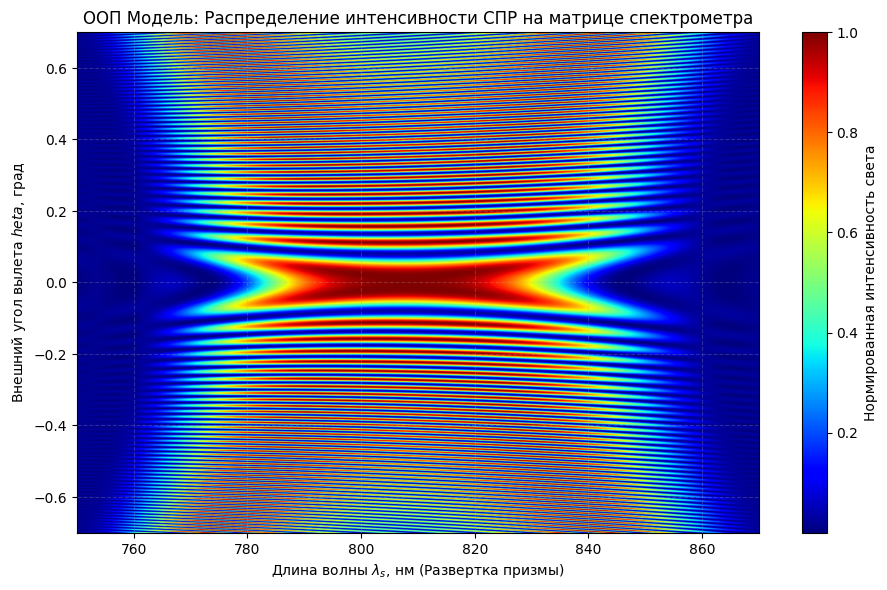

Расчет для толщин слоя: [ 10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.  70.  75.
  80.  85.  90.  95. 100.] мм
Расчет матрицы интерференции (зависимость от зазора)...
Матричный график сохранен: 'spdc_interference_grid_by_gap.png'
Расчет среза для среднего зазора 55.00 мм...
Срез сохранен в 'spdc_theta_slice_by_gap.png'


In [5]:
# Инициализируем материалы
air = Air()
bbo = BBO()
glass = GlassBK7()

# Создаем объект эксперимента (накачка 404 нм задана внутри по умолчанию)
experiment_gap = SPDCExperiment()

# Набираем слои («пирог» нашего стенда)
experiment_gap.add_layer(Layer(bbo, thickness=3.0e-3, pol_p="eff", is_source=True, name="Кристалл 1 (BBO)"))
experiment_gap.add_layer(Layer(air, thickness=213e-3, is_source=False, name="Воздушный зазор 1"))
experiment_gap.add_layer(Layer(bbo, thickness=4.3e-3, pol_p="eff", is_source=True, name="Кристалл 2 (BBO)"))

# 1. Запускаем бенчмарк угловой фазы для промежуточных сред
experiment_gap.run_angular_phase_benchmark()

# 2. Строим 2D картинку интерференции, которая полетит на камеру спектрометра
experiment_gap.plot_experiment_image(theta_range_deg=(-0.7, 0.7), lambda_range_nm=(750, 870))
generate_and_save_plots_by_gap(experiment_gap, gap_params=(10e-3,100e-3,5e-3))

In [6]:
# Запуск расчетов и сохранения графиков
generate_and_save_plots(experiment)


Расчет для углов: [-12. -10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.  12.  14.] градусов
Расчет матрицы интерференции...
Матричный график сохранен. Использовано углов: 14 из 15
Расчет одномерного среза по углам...
Срез по углам успешно сохранен в 'spdc_theta_slice_808nm.png'
